/tmp/ipykernel_33157/2101954123.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_co2_fuel_selected['Total Emissions'] = df_co2_fuel_selected.groupby(['country', 'year'])['CO2 Emissions'].transform('sum')
/tmp/ipykernel_33157/2101954123.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_co2_fuel_selected['Share'] = df_co2_fuel_selected['CO2 Emissions'] / df_co2_fuel_selected['Total Emissions']


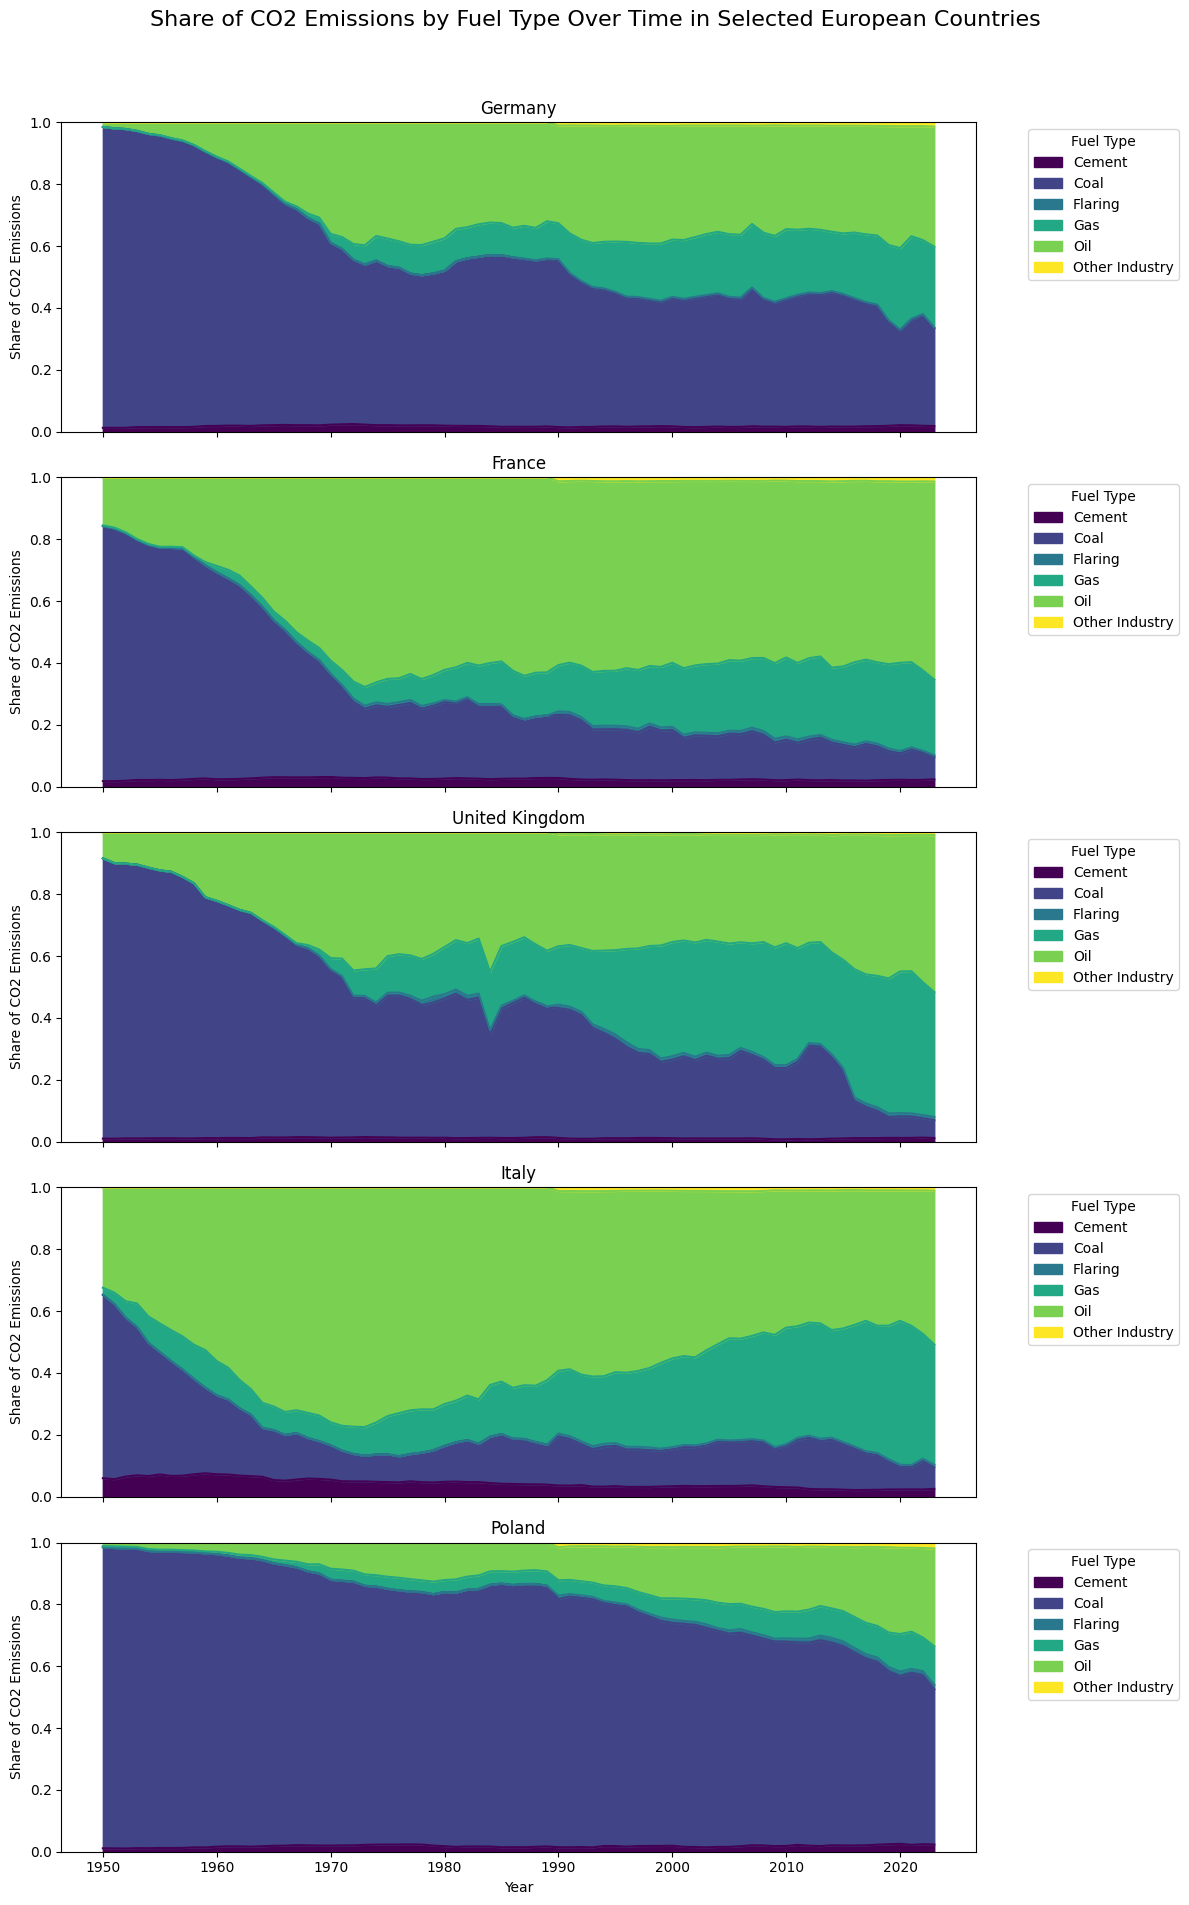

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# List of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and relevant years (e.g., from 1950 onwards for better data availability)
df_co2_europe = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries) & (owid_co2_data_df['year'] >= 1950)].copy()

# Select relevant CO2 emission columns by fuel type
co2_fuel_cols = ['country', 'year', 'coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']
df_co2_fuel = df_co2_europe[co2_fuel_cols].copy()

# Fill NaN values with 0 for CO2 fuel columns before melting
for col in ['coal_co2', 'oil_co2', 'gas_co2', 'cement_co2', 'flaring_co2', 'other_industry_co2']:
    df_co2_fuel[col] = df_co2_fuel[col].fillna(0)

# Melt the DataFrame to have fuel types as a single column
df_co2_fuel_melted = df_co2_fuel.melt(id_vars=['country', 'year'],
                                      var_name='Fuel Type',
                                      value_name='CO2 Emissions')

# Rename fuel type categories for better readability
df_co2_fuel_melted['Fuel Type'] = df_co2_fuel_melted['Fuel Type'].replace({
    'coal_co2': 'Coal',
    'oil_co2': 'Oil',
    'gas_co2': 'Gas',
    'cement_co2': 'Cement',
    'flaring_co2': 'Flaring',
    'other_industry_co2': 'Other Industry'
})

# Select a few key countries to visualize to avoid too much clutter
selected_countries_v3 = ['Germany', 'France', 'United Kingdom', 'Italy', 'Poland']
df_co2_fuel_selected = df_co2_fuel_melted[df_co2_fuel_melted['country'].isin(selected_countries_v3)]

# Calculate the total emissions for normalization within each country and year
df_co2_fuel_selected['Total Emissions'] = df_co2_fuel_selected.groupby(['country', 'year'])['CO2 Emissions'].transform('sum')
df_co2_fuel_selected['Share'] = df_co2_fuel_selected['CO2 Emissions'] / df_co2_fuel_selected['Total Emissions']

# Plotting with Matplotlib and Seaborn
fig, axes = plt.subplots(len(selected_countries_v3), 1, figsize=(12, 4 * len(selected_countries_v3)), sharex=True)
fig.suptitle('Share of CO2 Emissions by Fuel Type Over Time in Selected European Countries', fontsize=16)

for i, country in enumerate(selected_countries_v3):
    ax = axes[i]
    country_data = df_co2_fuel_selected[df_co2_fuel_selected['country'] == country]

    # Pivot for stacked area plot
    pivot_data = country_data.pivot(index='year', columns='Fuel Type', values='Share').fillna(0)
    pivot_data.plot.area(ax=ax, stacked=True, cmap='viridis')

    ax.set_title(country)
    ax.set_ylabel('Share of CO2 Emissions')
    ax.set_xlabel('Year')
    ax.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_ylim(0, 1) # Ensure y-axis is from 0 to 1 for share

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

In [2]:
import pandas as pd
import plotly.express as px

# Load the dataset
data2_df = pd.read_csv('data2.csv', skiprows=8)

# List of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for relevant data
df_renewables_v6 = data2_df[
    (data2_df['Balance'] == 'Net Electricity Production') &
    (data2_df['Unit'] == 'GWh') &
    (data2_df['Country'].isin(european_countries))
].copy()

# Convert 'Time' to datetime objects
# Handle potential errors during conversion by coercing invalid dates to NaT
df_renewables_v6['Date_Parsed'] = pd.to_datetime(df_renewables_v6['Time'], format='%B %Y', errors='coerce')

# Drop rows where Date_Parsed is NaT due to parsing errors
df_renewables_v6.dropna(subset=['Date_Parsed'], inplace=True)

# Filter for relevant renewable product types
renewable_products = ['Hydro', 'Solar', 'Wind', 'Biofuels', 'Geothermal', 'Other renewables']
df_renewables_v6_filtered = df_renewables_v6[df_renewables_v6['Product'].isin(renewable_products)]

# Aggregate total generation by Date_Parsed and Product across all European countries
df_renewables_total_europe = df_renewables_v6_filtered.groupby(['Date_Parsed', 'Product'])['Value'].sum().reset_index()

# Sort by Date_Parsed for proper area chart display
df_renewables_total_europe = df_renewables_total_europe.sort_values(by='Date_Parsed')

# Create the stacked area chart with Plotly Express
fig = px.area(df_renewables_total_europe,
              x='Date_Parsed',
              y='Value',
              color='Product',
              title='Share of Renewable Energy Sources in European Electricity Production',
              labels={'Date_Parsed': 'Date', 'Value': 'Electricity Generation (GWh)', 'Product': 'Renewable Source'},
              line_group='Product', # Ensures proper stacking for different products
              # For normalized stack, use groupnorm
              groupnorm='fraction' # To show share (normalized stack)
             )

fig.update_layout(yaxis_tickformat=".0%") # Format y-axis as percentage
fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Share of Renewable Generation')

fig.show()

In [3]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 1. Data inlezen en filteren
df = (
    pd.read_csv("data2.csv", skiprows=8)
      .query("Balance=='Net Electricity Production' and Product=='Electricity' and Time=='March 2025'")
      .loc[lambda d: d['Country'].isin([
          'Austria','Belgium','Bulgaria','Croatia','Cyprus','Czech Republic',
          'Denmark','Estonia','Finland','France','Germany','Greece',
          'Hungary','Ireland','Italy','Latvia','Lithuania','Luxembourg',
          'Malta','Netherlands','Poland','Portugal','Romania','Slovakia',
          'Slovenia','Spain','Sweden'
      ])]
      .assign(
          gwh=lambda d: d['Value'].round(1),
          iso_a3=lambda d: d['Country'].map({
              'Austria':'AUT','Belgium':'BEL','Bulgaria':'BGR','Croatia':'HRV',
              'Cyprus':'CYP','Czech Republic':'CZE','Denmark':'DNK','Estonia':'EST',
              'Finland':'FIN','France':'FRA','Germany':'DEU','Greece':'GRC',
              'Hungary':'HUN','Ireland':'IRL','Italy':'ITA','Latvia':'LVA',
              'Lithuania':'LTU','Luxembourg':'LUX','Malta':'MLT','Netherlands':'NLD',
              'Poland':'POL','Portugal':'PRT','Romania':'ROU','Slovakia':'SVK',
              'Slovenia':'SVN','Spain':'ESP','Sweden':'SWE'
          })
      )
      .drop(columns=['Balance','Product','Time','Value'])
)

# 2. Prepare sorted bar data
df_bar = df.sort_values("gwh", ascending=True)

# 3. Maak een subplot-figuur: 1 rij, 2 kolommen (map + bar)
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.6, 0.4],
    specs=[[{"type": "choropleth"}, {"type": "xy"}]],
    subplot_titles=(
        "Geografische spreiding<br><sup>Groen = laag, Rood = hoog</sup>",
        "Rangorde productie per land"
    )
)

# 4. Voeg choropleth toe
fig.add_trace(
    go.Choropleth(
        locations=df['iso_a3'],
        z=df['gwh'],
        text=df['Country'],
        colorscale="RdYlGn_r",
        zmin=df['gwh'].min(), zmax=df['gwh'].max(),
        colorbar=dict(title="GWh", tickformat=",", len=0.6, y=0.5),
        marker_line_color="white", marker_line_width=0.5,
        hovertemplate="<b>%{text}</b><br>%{z:,.1f} GWh<extra></extra>"
    ),
    row=1, col=1
)

# 5. Voeg horizontale bar chart toe
fig.add_trace(
    go.Bar(
        x=df_bar['gwh'],
        y=df_bar['Country'],
        orientation='h',
        marker=dict(color=df_bar['gwh'], colorscale="RdYlGn_r", cmin=df['gwh'].min(), cmax=df['gwh'].max()),
        hovertemplate="%{y}: %{x:,.1f} GWh<extra></extra>"
    ),
    row=1, col=2
)

# 6. Layout-optimalisaties
fig.update_layout(
    title_text="Energieproductie EU-27 – Maart 2025",
    title_x=0.5,
    template="plotly_white",
    margin=dict(l=10, r=10, t=80, b=20)
)
fig.update_geos(
    scope="europe",
    projection_type="mercator",
    showcountries=False, showsubunits=False,
    lataxis_range=[34, 72], lonaxis_range=[-10, 35]
)

# 7. Toon de figuur
fig.show()






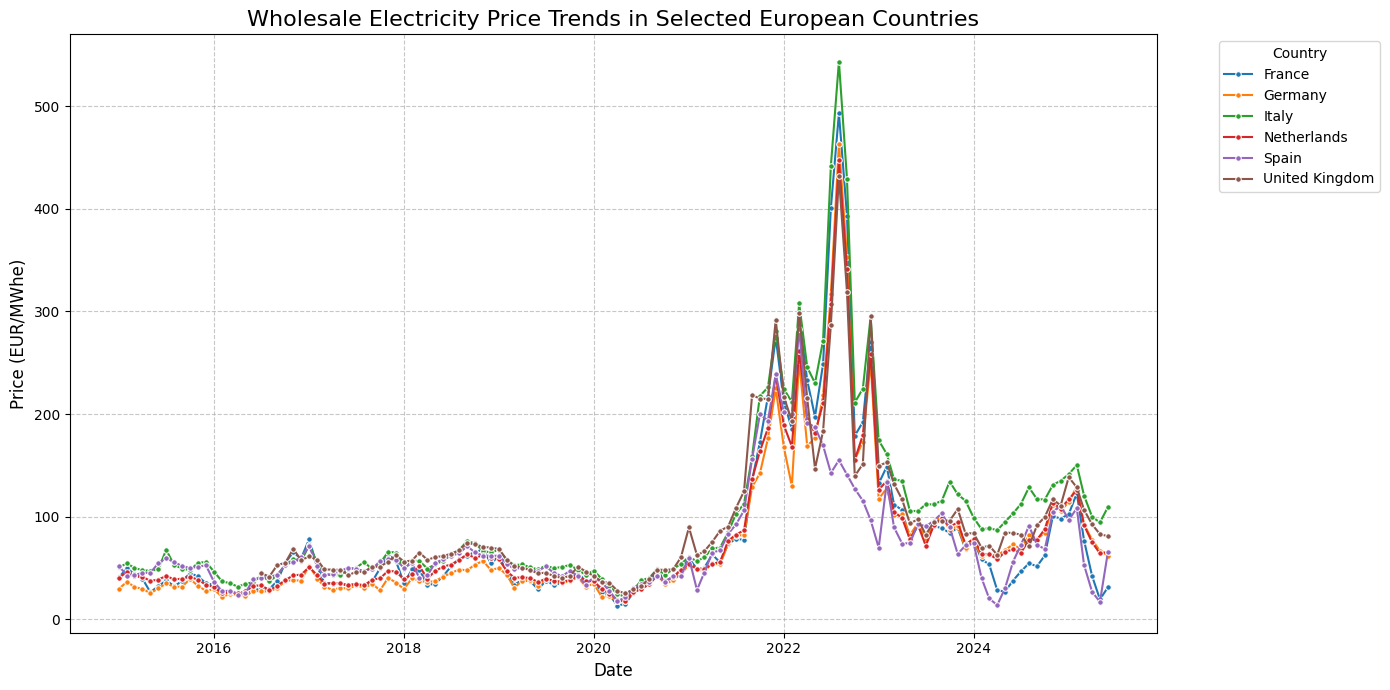

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
european_electricity_prices_df = pd.read_csv('european_wholesale_electricity_price_data_monthly.csv')

# Convert 'Date' to datetime objects
european_electricity_prices_df['Date'] = pd.to_datetime(european_electricity_prices_df['Date'])

# Filter for relevant years (e.g., from 2015 onwards as per the data head)
df_prices = european_electricity_prices_df[european_electricity_prices_df['Date'].dt.year >= 2015].copy()

# Select a few key countries to visualize
selected_countries_v4 = ['Germany', 'France', 'United Kingdom', 'Spain', 'Italy', 'Netherlands']
df_prices_selected = df_prices[df_prices['Country'].isin(selected_countries_v4)]

# Plotting with Matplotlib and Seaborn
plt.figure(figsize=(14, 7))
sns.lineplot(data=df_prices_selected, x='Date', y='Price (EUR/MWhe)', hue='Country', marker='o', lw=1.5, markersize=4)

plt.title('Wholesale Electricity Price Trends in Selected European Countries', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (EUR/MWhe)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

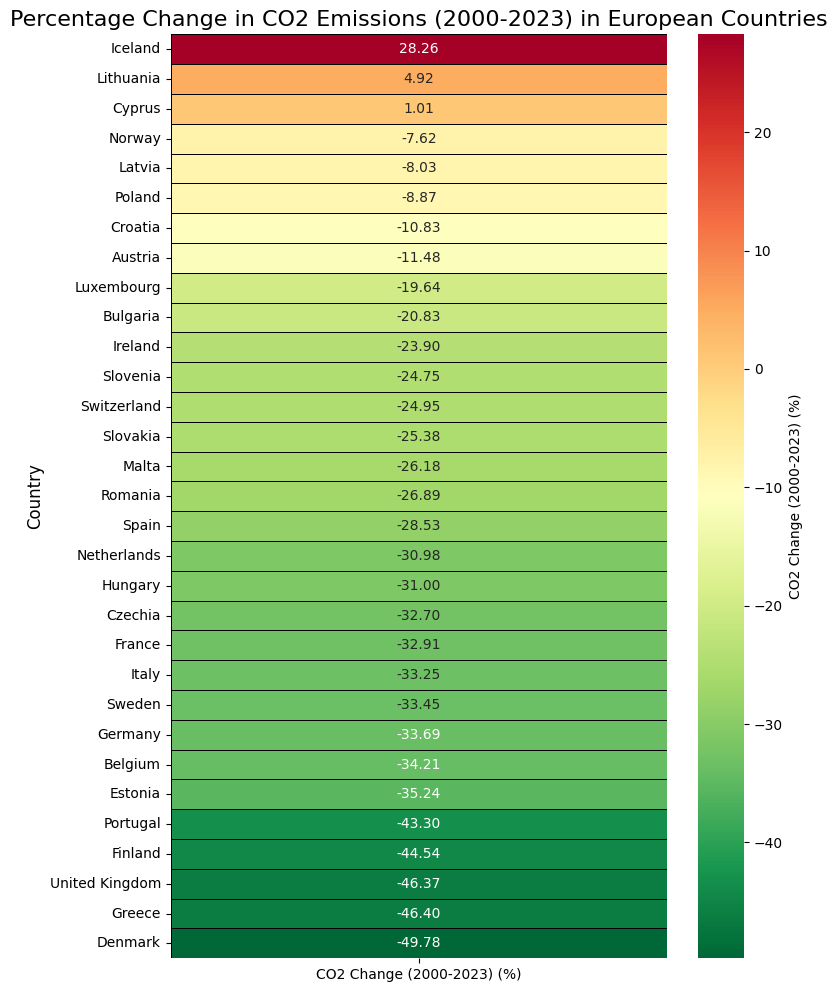

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# List of European countries (can be adjusted)
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and relevant years
start_year_v8 = 2000
end_year_v8 = owid_co2_data_df['year'].max() # Get the latest year available in the dataset

df_co2_change = owid_co2_data_df[
    (owid_co2_data_df['country'].isin(european_countries)) &
    ((owid_co2_data_df['year'] == start_year_v8) | (owid_co2_data_df['year'] == end_year_v8))
].copy()

# Pivot the table to get start and end year CO2 emissions side by side for each country
df_co2_pivot = df_co2_change.pivot_table(index='country', columns='year', values='co2').reset_index()
df_co2_pivot.columns.name = None # Remove the columns name attribute

# Calculate percentage change
df_co2_pivot['CO2 Change (%)'] = ((df_co2_pivot[end_year_v8] - df_co2_pivot[start_year_v8]) / df_co2_pivot[start_year_v8]) * 100

# Drop rows with NaN values in 'CO2 Change (%)' (countries for which data is not complete for both years)
df_co2_change_final = df_co2_pivot.dropna(subset=['CO2 Change (%)']).sort_values(by='CO2 Change (%)', ascending=False)

# Prepare data for heatmap: reshape to a single column for the value to be mapped to color
# For a single column, a bar chart or a "strip" heatmap is typically used.
# To make it a heatmap, we can create a dummy column.
df_heatmap_data = df_co2_change_final[['country', 'CO2 Change (%)']].copy()
df_heatmap_data['Metric'] = f'CO2 Change ({start_year_v8}-{end_year_v8}) (%)'

# Create a pivot table suitable for heatmap (country vs. metric)
heatmap_pivot = df_heatmap_data.pivot_table(index='country', columns='Metric', values='CO2 Change (%)')

# Sort the index of the pivot table to match the sorted order from df_co2_change_final
heatmap_pivot = heatmap_pivot.reindex(df_co2_change_final['country'])


plt.figure(figsize=(8, 12))
sns.heatmap(heatmap_pivot,
            annot=True,
            cmap='RdYlGn_r', # Red-Yellow-Green, reversed for green (good/reduction) to red (bad/increase)
            fmt=".2f",
            linewidths=.5,
            linecolor='black',
            cbar_kws={'label': f'CO2 Change ({start_year_v8}-{end_year_v8}) (%)'})

plt.title(f'Percentage Change in CO2 Emissions ({start_year_v8}-{end_year_v8}) in European Countries', fontsize=16)
plt.ylabel('Country', fontsize=12)
plt.yticks(rotation=0) # Keep country names horizontal
plt.xlabel('') # Remove x-label as it's a dummy column
plt.show()

In [6]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries
df_europe = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries)].copy()

# Select relevant columns and drop rows with any missing values for these columns
# 'primary_energy_consumption' is used as a proxy for 'energy production'
# 'temperature_change_from_ghg' is used for 'temperature change'
df_filtered = df_europe[['country', 'year', 'gdp', 'primary_energy_consumption', 'temperature_change_from_ghg']].dropna()

# Ensure numeric types
df_filtered['gdp'] = pd.to_numeric(df_filtered['gdp'])
df_filtered['primary_energy_consumption'] = pd.to_numeric(df_filtered['primary_energy_consumption'])
df_filtered['temperature_change_from_ghg'] = pd.to_numeric(df_filtered['temperature_change_from_ghg'])

# Create the scatter plot with three variables
# GDP on X-axis, Temperature Change on Y-axis, Primary Energy Consumption mapped to size
# Color by Country to distinguish, and animate by Year to show evolution
fig = px.scatter(df_filtered,
                 x="gdp",
                 y="temperature_change_from_ghg",
                 size="primary_energy_consumption",
                 color="country",
                 hover_name="country",
                 animation_frame="year",
                 log_x=True, # GDP can span a large range, so a log scale is often useful
                 title="GDP, Energy Consumption, and Temperature Change in Europe Over Time",
                 labels={
                     "gdp": "GDP (current USD)",
                     "temperature_change_from_ghg": "Temperature Change from GHG Emissions (°C)",
                     "primary_energy_consumption": "Primary Energy Consumption (terawatt-hours)"
                 },
                 size_max=60) # Adjust size_max for better visualization of points

# Update layout for better readability and interactivity
fig.update_layout(
    xaxis_title="GDP (current USD, log scale)",
    yaxis_title="Temperature Change from GHG Emissions (°C)",
    hovermode="closest"
)

# Show the plot
fig.show()


In [7]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries
df_europe = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries)].copy()

# Select relevant columns and drop rows with any missing values
df_filtered = df_europe[['country', 'year', 'primary_energy_consumption', 'temperature_change_from_ghg']].dropna()

# Ensure numeric types
df_filtered['primary_energy_consumption'] = pd.to_numeric(df_filtered['primary_energy_consumption'])
df_filtered['temperature_change_from_ghg'] = pd.to_numeric(df_filtered['temperature_change_from_ghg'])

# Create the scatter plot
fig = px.scatter(df_filtered,
                 x="primary_energy_consumption",
                 y="temperature_change_from_ghg",
                 color="country",
                 hover_name="country",
                 animation_frame="year", # Animate over years
                 log_x=True, # Energy consumption can also vary widely
                 title="Primary Energy Consumption vs. Temperature Change in Europe Over Time",
                 labels={
                     "primary_energy_consumption": "Primary Energy Consumption (terawatt-hours)",
                     "temperature_change_from_ghg": "Temperature Change from GHG Emissions (°C)"
                 })

# Update layout for better readability and interactivity
fig.update_layout(
    xaxis_title="Primary Energy Consumption (terawatt-hours, log scale)",
    yaxis_title="Temperature Change from GHG Emissions (°C)",
    hovermode="closest"
)

# Show the plot
fig.show()


In [8]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries
df_europe = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries)].copy()

# Select relevant columns and drop rows with any missing values
df_filtered = df_europe[['country', 'year', 'gdp', 'temperature_change_from_ghg']].dropna()

# Ensure numeric types
df_filtered['gdp'] = pd.to_numeric(df_filtered['gdp'])
df_filtered['temperature_change_from_ghg'] = pd.to_numeric(df_filtered['temperature_change_from_ghg'])

# Create the scatter plot
fig = px.scatter(df_filtered,
                 x="gdp",
                 y="temperature_change_from_ghg",
                 color="country",
                 hover_name="country",
                 animation_frame="year", # Animate over years
                 log_x=True, # GDP can span a large range
                 title="GDP vs. Temperature Change in Europe Over Time",
                 labels={
                     "gdp": "GDP (current USD)",
                     "temperature_change_from_ghg": "Temperature Change from GHG Emissions (°C)"
                 })

# Update layout for better readability and interactivity
fig.update_layout(
    xaxis_title="GDP (current USD, log scale)",
    yaxis_title="Temperature Change from GHG Emissions (°C)",
    hovermode="closest"
)

# Show the plot
fig.show()


In [9]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries
df_europe = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries)].copy()

# Find the latest year with data for each country
# For a distribution, we typically want a snapshot in time. Let's take the latest available year globally for consistency,
# or the latest year for which 'co2_per_capita' is not NaN for most countries.
latest_year = df_europe['year'].max()
df_latest_year = df_europe[df_europe['year'] == latest_year].dropna(subset=['co2_per_capita']).copy()

# If latest_year doesn't yield enough data, consider a slightly older but more complete year, or handle NaNs specifically.
# For simplicity, we'll just take the max year and dropna.

# Create the box plot
fig = px.box(df_latest_year,
             y="co2_per_capita",
             x="country", # Display individual countries on x-axis to see their exact values
             points="all", # Show individual data points
             title=f"Distribution of CO2 Emissions per Capita in European Countries ({latest_year})",
             labels={
                 "co2_per_capita": "CO2 Emissions per Capita (tonnes)"
             },
             hover_name="country",
             hover_data={'co2_per_capita': ':.2f'}) # Format tooltip for CO2 per capita

fig.update_layout(
    xaxis_title="Country",
    yaxis_title="CO2 Emissions per Capita (tonnes)",
    xaxis_tickangle=-45 # Rotate x-axis labels for readability
)

# Show the plot
fig.show()


In [10]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and a recent period (e.g., 2010 onwards)
df_europe_recent = owid_co2_data_df[
    (owid_co2_data_df['country'].isin(european_countries)) &
    (owid_co2_data_df['year'] >= 2010)
].copy()

# Select relevant columns for correlation analysis
# 'co2' is total CO2 emissions, 'primary_energy_consumption' for energy production
correlation_cols = ['gdp', 'co2', 'primary_energy_consumption', 'temperature_change_from_ghg']

# Calculate the mean of these variables for each country over the recent period
# This helps in getting a representative value for correlation, rather than year-specific fluctuations
df_aggregated = df_europe_recent.groupby('country')[correlation_cols].mean().dropna()

# Calculate the correlation matrix
correlation_matrix = df_aggregated.corr()

# Rename columns for better display in the heatmap
correlation_matrix.columns = ['GDP', 'CO2 Emissions', 'Primary Energy Consumption', 'Temperature Change']
correlation_matrix.index = ['GDP', 'CO2 Emissions', 'Primary Energy Consumption', 'Temperature Change']


# Create the heatmap using plotly.graph_objects
fig = go.Figure(data=go.Heatmap(
        z=correlation_matrix.values,
        x=correlation_matrix.columns.tolist(),
        y=correlation_matrix.index.tolist(),
        colorscale='RdBu', # Red-Blue diverging colormap (e.g., red for negative, blue for positive)
        zmin=-1, zmax=1, # Correlation values range from -1 to 1
        colorbar=dict(title='Correlation Coefficient')
    ))

fig.update_layout(
    title='Correlation Matrix of Key Economic/Environmental Indicators in Europe (Avg. 2010-Latest)',
    xaxis_title="Indicators",
    yaxis_title="Indicators",
    xaxis_nticks=len(correlation_matrix.columns),
    yaxis_nticks=len(correlation_matrix.index)
)

# Add annotations (correlation values) to the heatmap
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        fig.add_annotation(
            x=correlation_matrix.columns[j],
            y=correlation_matrix.index[i],
            text=f"{correlation_matrix.iloc[i, j]:.2f}",
            showarrow=False,
            font=dict(color="black" if abs(correlation_matrix.iloc[i,j]) < 0.5 else "white") # Make text readable
        )

# Show the plot
fig.show()


In [11]:
import pandas as pd
import plotly.express as px

# Load the dataset
data2_df = pd.read_csv('data2.csv', skiprows=8)

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for relevant data: European countries, 'Net Electricity Production', 'GWh' unit
df_renewables_prod = data2_df[
    (data2_df['Balance'] == 'Net Electricity Production') &
    (data2_df['Unit'] == 'GWh') &
    (data2_df['Country'].isin(european_countries))
].copy()

# Convert 'Time' to datetime objects, coercing errors
df_renewables_prod['Date_Parsed'] = pd.to_datetime(df_renewables_prod['Time'], format='%B %Y', errors='coerce')
df_renewables_prod.dropna(subset=['Date_Parsed'], inplace=True) # Drop rows where date parsing failed

# Identify relevant renewable product types
renewable_products = ['Hydro', 'Solar', 'Wind', 'Biofuels', 'Geothermal', 'Other renewables']
df_renewables_prod_filtered = df_renewables_prod[df_renewables_prod['Product'].isin(renewable_products)]

# Find the latest available date for each country-product combination
# Then, get the overall latest date from this subset
latest_date_overall = df_renewables_prod_filtered['Date_Parsed'].max()
df_latest_data = df_renewables_prod_filtered[df_renewables_prod_filtered['Date_Parsed'] == latest_date_overall].copy()

# Aggregate production by Country and Product for the latest date
df_aggregated = df_latest_data.groupby(['Country', 'Product'])['Value'].sum().reset_index()
df_aggregated.rename(columns={'Value': 'Production (GWh)'}, inplace=True)


# Create the Sunburst chart
fig = px.sunburst(df_aggregated,
                  path=['Country', 'Product'], # Hierarchy: Country -> Product
                  values='Production (GWh)',
                  title=f"Renewable Electricity Production Breakdown in Europe ({latest_date_overall.strftime('%B %Y')})",
                  labels={'Production (GWh)': 'Production (GWh)'})

# Update layout for better readability
fig.update_layout(margin=dict(t=50, l=0, r=0, b=0)) # Adjust margins

# Show the plot
fig.show()


In [12]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and a relevant time period (e.g., last few decades)
# Ensure 'co2_per_capita' is not NaN
df_co2_per_capita = owid_co2_data_df[
    (owid_co2_data_df['country'].isin(european_countries)) &
    (owid_co2_data_df['year'] >= 1990) # Start from 1990 for a more recent view
].dropna(subset=['co2_per_capita']).copy()

# Pivot the table for the heatmap: countries as rows, years as columns, co2_per_capita as values
heatmap_data = df_co2_per_capita.pivot_table(index='country', columns='year', values='co2_per_capita')

# Sort countries alphabetically for consistent display
heatmap_data = heatmap_data.sort_index()

# Create the heatmap
fig = go.Figure(data=go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns.tolist(),
        y=heatmap_data.index.tolist(),
        colorscale='Viridis', # Choose a cool colormap, e.g., 'Viridis', 'Plasma', 'Cividis'
        colorbar=dict(title='CO2 per Capita (tonnes)')
    ))

fig.update_layout(
    title='Evolution of CO2 Emissions per Capita in European Countries (1990-Latest)',
    xaxis_title="Year",
    yaxis_title="Country",
    xaxis_nticks=len(heatmap_data.columns), # Ensure all years are shown if possible
    yaxis_nticks=len(heatmap_data.index), # Ensure all countries are shown
    xaxis_type='category' # Treat years as categories to prevent scaling issues
)

# Show the plot
fig.show()


In [13]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and relevant columns
df_energy_gdp = owid_co2_data_df[
    (owid_co2_data_df['country'].isin(european_countries)) &
    (owid_co2_data_df['year'] >= 1990) # Focus on recent decades
].copy()

# Calculate energy intensity: primary_energy_consumption / gdp
# Handle potential division by zero or NaN GDP/energy consumption
df_energy_gdp['energy_intensity'] = df_energy_gdp['primary_energy_consumption'] / df_energy_gdp['gdp']

# Drop rows where energy_intensity is NaN or infinite (due to missing data or zero GDP)
df_energy_gdp.dropna(subset=['energy_intensity'], inplace=True)
df_energy_gdp = df_energy_gdp[df_energy_gdp['energy_intensity'] != 0]

# Create a 'decade' column for grouping
df_energy_gdp['decade'] = (df_energy_gdp['year'] // 10) * 10
# Convert decade to string for categorical x-axis
df_energy_gdp['decade'] = df_energy_gdp['decade'].astype(str) + 's'


# Create the violin plot
fig = px.violin(df_energy_gdp,
                x="decade",
                y="energy_intensity",
                box=True, # Show box plot inside the violin
                points="outliers", # Show only outliers as points
                color="decade", # Color by decade
                title="Distribution of Energy Intensity (Primary Energy Consumption/GDP) by Decade in Europe",
                labels={
                    "energy_intensity": "Primary Energy Consumption / GDP (Terawatt-hours / USD)",
                    "decade": "Decade"
                },
                hover_data={'country': True, 'year': True}) # Show country and year on hover

fig.update_layout(
    xaxis_title="Decade",
    yaxis_title="Energy Intensity (Terawatt-hours / USD)"
)

# Show the plot
fig.show()


In [14]:
import pandas as pd
import plotly.graph_objects as go

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# --- Identify the top 10 most populous countries ---
# Get the latest population for each country
latest_population = owid_co2_data_df.dropna(subset=['population']).groupby('country')['population'].max().reset_index()

# Sort by population in descending order and get the top 10
top_10_populous_countries = latest_population.sort_values(by='population', ascending=False).head(10)['country'].tolist()

print(f"Top 10 most populous countries: {top_10_populous_countries}")

# Filter for these top 10 countries and a relevant time period (e.g., last few decades)
# Ensure 'co2_per_capita' is not NaN
df_co2_top10 = owid_co2_data_df[
    (owid_co2_data_df['country'].isin(top_10_populous_countries)) &
    (owid_co2_data_df['year'] >= 1990) # Start from 1990 for a more recent view
].dropna(subset=['co2_per_capita']).copy()

# Pivot the table for the heatmap: countries as rows, years as columns, co2_per_capita as values
heatmap_data = df_co2_top10.pivot_table(index='country', columns='year', values='co2_per_capita')

# Reindex to ensure the order of countries in the heatmap matches the order from the top_10_populous_countries list
heatmap_data = heatmap_data.reindex(top_10_populous_countries)

# Create the heatmap
fig = go.Figure(data=go.Heatmap(
        z=heatmap_data.values,
        x=heatmap_data.columns.tolist(),
        y=heatmap_data.index.tolist(),
        colorscale='Viridis', # Or 'Plasma', 'Cividis', 'YlOrRd'
        colorbar=dict(title='CO2 per Capita (tonnes)'),
        hovertemplate="<b>Country:</b> %{y}<br>" +
                      "<b>Year:</b> %{x}<br>" +
                      "<b>CO2 per Capita:</b> %{z:.2f} tonnes<extra></extra>"
    ))

fig.update_layout(
    title='Evolution of CO2 Emissions per Capita (Top 10 Most Populous Countries, 1990-Latest)',
    xaxis_title="Year",
    yaxis_title="Country",
    xaxis_nticks=len(heatmap_data.columns), # Ensure all years are shown if possible
    yaxis_nticks=len(heatmap_data.index), # Ensure all countries are shown
    xaxis_type='category', # Treat years as categories to prevent scaling issues
    height=600 # Adjust height for better readability
)

# Show the plot
fig.show()


Top 10 most populous countries: ['World', 'Asia', 'Lower-middle-income countries', 'Upper-middle-income countries', 'Asia (excl. China and India)', 'Africa', 'India', 'China', 'High-income countries', 'Europe']


In [15]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Filter for European countries and select relevant columns
df_europe_co2 = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries)].copy()

# Find the latest year with CO2 data for each country
latest_year_co2 = df_europe_co2.dropna(subset=['co2']).groupby('country')['year'].max().reset_index()
df_latest_co2_data = pd.merge(df_europe_co2, latest_year_co2, on=['country', 'year'])

# Ensure 'iso_code' is available for plotting (Plotly needs ISO codes for countries)
df_latest_co2_data.dropna(subset=['iso_code', 'co2'], inplace=True)

# Create the choropleth map
fig = px.choropleth(df_latest_co2_data,
                    locations="iso_code",
                    color="co2", # Data to be colored
                    hover_name="country",
                    hover_data={"co2": ":.2f", "year": True}, # Show CO2 formatted and year
                    color_continuous_scale=px.colors.sequential.Plasma, # Choose a color scale
                    projection="natural earth", # A good projection for global/continental maps
                    title=f"Total CO2 Emissions in Europe ({df_latest_co2_data['year'].max()} Data)",
                    labels={'co2': 'Total CO2 Emissions (million tonnes)'})

# Focus the map on Europe (adjusting the scope and center)
fig.update_geos(
    scope='europe',
    lataxis_range=[30, 75], # Latitude range for Europe
    lonaxis_range=[-25, 45], # Longitude range for Europe
    showcountries=True, countrycolor="Black"
)

fig.update_layout(height=600) # Adjust height for better visibility

# Show the plot
fig.show()


In [16]:
import pandas as pd
import plotly.express as px

# Load the datasets
owid_co2_data_df = pd.read_csv('owid-co2-data.csv') # To get ISO codes
data2_df = pd.read_csv('data2.csv', skiprows=8)

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# --- Process data2_df for renewable share ---
df_electricity_prod = data2_df[
    (data2_df['Balance'] == 'Net Electricity Production') &
    (data2_df['Unit'] == 'GWh') &
    (data2_df['Country'].isin(european_countries))
].copy()

# Convert 'Time' to datetime objects
df_electricity_prod['Date_Parsed'] = pd.to_datetime(df_electricity_prod['Time'], format='%B %Y', errors='coerce')
df_electricity_prod.dropna(subset=['Date_Parsed'], inplace=True)

# Get the latest overall date in this filtered dataset
latest_date_prod = df_electricity_prod['Date_Parsed'].max()
df_latest_prod_data = df_electricity_prod[df_electricity_prod['Date_Parsed'] == latest_date_prod].copy()

# Identify renewable and total electricity products
renewable_products = ['Hydro', 'Solar', 'Wind', 'Biofuels', 'Geothermal', 'Other renewables']
total_products = ['Electricity', 'Total Combustible Fuels'] # 'Electricity' should be total net, 'Total Combustible Fuels' for fossil

# Calculate total renewable production per country
df_renewables_agg = df_latest_prod_data[df_latest_prod_data['Product'].isin(renewable_products)].groupby('Country')['Value'].sum().reset_index()
df_renewables_agg.rename(columns={'Value': 'Renewable_Production_GWh'}, inplace=True)

# Calculate total electricity production (or a proxy for it)
# Assuming 'Electricity' product represents total net electricity production in data2_df
df_total_electricity_agg = df_latest_prod_data[df_latest_prod_data['Product'] == 'Electricity'].groupby('Country')['Value'].sum().reset_index()
df_total_electricity_agg.rename(columns={'Value': 'Total_Electricity_Production_GWh'}, inplace=True)

# Merge to calculate share
df_merged_prod = pd.merge(df_renewables_agg, df_total_electricity_agg, on='Country', how='inner')
df_merged_prod['Renewable_Share (%)'] = (df_merged_prod['Renewable_Production_GWh'] / df_merged_prod['Total_Electricity_Production_GWh']) * 100

# --- Merge with owid-co2-data_df to get ISO codes ---
# Create a mapping from country name to ISO code from owid_co2_data_df
country_to_iso = owid_co2_data_df[['country', 'iso_code']].dropna().drop_duplicates(subset=['country'])
df_merged_prod_with_iso = pd.merge(df_merged_prod, country_to_iso, left_on='Country', right_on='country', how='left')
df_merged_prod_with_iso.drop(columns='country', inplace=True) # Drop redundant country column

# Drop rows if ISO code is missing
df_merged_prod_with_iso.dropna(subset=['iso_code', 'Renewable_Share (%)'], inplace=True)

# Create the choropleth map
fig = px.choropleth(df_merged_prod_with_iso,
                    locations="iso_code",
                    color="Renewable_Share (%)", # Data to be colored
                    hover_name="Country",
                    hover_data={"Renewable_Share (%)": ":.2f", "Renewable_Production_GWh": ":.0f", "Total_Electricity_Production_GWh": ":.0f"},
                    color_continuous_scale=px.colors.sequential.Greens, # Green scale for renewable share
                    projection="natural earth",
                    title=f"Renewable Electricity Share in European Production ({latest_date_prod.strftime('%B %Y')})",
                    labels={'Renewable_Share (%)': 'Renewable Electricity Share (%)'})

# Focus the map on Europe
fig.update_geos(
    scope='europe',
    lataxis_range=[30, 75],
    lonaxis_range=[-25, 45],
    showcountries=True, countrycolor="Black"
)

fig.update_layout(height=600)

# Show the plot
fig.show()


In [17]:
import pandas as pd
import plotly.express as px

# Load the datasets
european_electricity_prices_df = pd.read_csv('european_wholesale_electricity_price_data_monthly.csv')
owid_co2_data_df = pd.read_csv('owid-co2-data.csv') # Used to get ISO codes

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Convert 'Date' to datetime objects
european_electricity_prices_df['Date'] = pd.to_datetime(european_electricity_prices_df['Date'])

# Filter for European countries
df_prices_europe = european_electricity_prices_df[european_electricity_prices_df['Country'].isin(european_countries)].copy()

# Find the latest date available in the dataset
latest_date_price = df_prices_europe['Date'].max()

# Filter for the latest month's data for each country
df_latest_prices = df_prices_europe[df_prices_europe['Date'] == latest_date_price].copy()

# --- Merge with owid-co2-data_df to get ISO codes ---
# Create a mapping from country name to ISO code from owid_co2_data_df
country_to_iso = owid_co2_data_df[['country', 'iso_code']].dropna().drop_duplicates(subset=['country'])

# Merge the latest prices data with ISO codes
# Use a common column name 'Country' for merging, or map 'ISO3 Code' from the price data if it's consistent
# The `european_electricity_prices_df` has 'Country' and 'ISO3 Code', let's use 'ISO3 Code' directly if it's reliable for Plotly
# However, Plotly typically uses 'iso_alpha' which is ISO A3 code. 'ISO3 Code' looks like it.
df_latest_prices.rename(columns={'ISO3 Code': 'iso_alpha'}, inplace=True)
df_latest_prices.dropna(subset=['iso_alpha', 'Price (EUR/MWhe)'], inplace=True)

# Create the choropleth map
fig = px.choropleth(df_latest_prices,
                    locations="iso_alpha", # Use the renamed ISO3 Code column
                    color="Price (EUR/MWhe)", # Data to be colored
                    hover_name="Country",
                    hover_data={"Price (EUR/MWhe)": ":.2f", "Date": "|%B %Y"}, # Format price and date
                    color_continuous_scale=px.colors.sequential.Plasma, # A good color scale for prices
                    projection="natural earth",
                    title=f"Wholesale Electricity Price in Europe ({latest_date_price.strftime('%B %Y')})",
                    labels={'Price (EUR/MWhe)': 'Price (EUR/MWhe)'})

# Focus the map on Europe
fig.update_geos(
    scope='europe',
    lataxis_range=[30, 75],
    lonaxis_range=[-25, 45],
    showcountries=True, countrycolor="Black"
)

fig.update_layout(height=600)

# Show the plot
fig.show()


In [18]:
import pandas as pd
import plotly.express as px

# Load the dataset
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')

# Define a list of European countries
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# Select a few key countries for this cumulative view (to avoid clutter)
selected_countries_cumulative = ['Germany', 'United Kingdom', 'France', 'Italy', 'Spain', 'Poland']

# Filter for selected European countries and years from 1950 onwards
df_cumulative = owid_co2_data_df[
    (owid_co2_data_df['country'].isin(selected_countries_cumulative)) &
    (owid_co2_data_df['year'] >= 1950)
].copy()

# Select the 'cumulative_co2' column and ensure it's numeric
df_cumulative_filtered = df_cumulative[['country', 'year', 'cumulative_co2']].dropna()
df_cumulative_filtered['cumulative_co2'] = pd.to_numeric(df_cumulative_filtered['cumulative_co2'])

# Create the stacked area chart for cumulative CO2 emissions
# We use an area chart here to visually represent the accumulation over time
fig = px.area(df_cumulative_filtered,
              x="year",
              y="cumulative_co2",
              color="country",
              line_group="country", # Ensures distinct lines for each country
              hover_name="country",
              title="Cumulative CO2 Emissions from Fossil Fuels in Selected European Countries (since 1950)",
              labels={
                  "year": "Year",
                  "cumulative_co2": "Cumulative CO2 Emissions (million tonnes)"
              })

fig.update_layout(
    xaxis_title="Year",
    yaxis_title="Cumulative CO2 Emissions (million tonnes)",
    hovermode="x unified" # Shows all values for a given year on hover
)

# Show the plot
fig.show()


In [19]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load the datasets
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')
european_electricity_prices_df = pd.read_csv('european_wholesale_electricity_price_data_monthly.csv')

# Define a list of European countries (consistent with previous plots)
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# --- Data Preparation for Graph 1 & 2 ---
# 1. Process electricity prices: Convert 'Date' to datetime and extract year, then calculate yearly average prices.
df_prices_yearly = european_electricity_prices_df.copy()
df_prices_yearly['Date'] = pd.to_datetime(df_prices_yearly['Date'])
df_prices_yearly['year'] = df_prices_yearly['Date'].dt.year

# Calculate the average wholesale electricity price per country per year
df_avg_yearly_prices = df_prices_yearly.groupby(['Country', 'year'])['Price (EUR/MWhe)'].mean().reset_index()
df_avg_yearly_prices.rename(columns={'Price (EUR/MWhe)': 'Average_Electricity_Price_EUR_MWh'}, inplace=True)

# 2. Filter CO2 data for European countries and select relevant columns.
df_co2_europe = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries)].copy()
# Select 'co2' (total CO2 emissions) and 'population' for context
df_co2_relevant = df_co2_europe[['country', 'year', 'co2', 'population']].dropna(subset=['co2'])

# 3. Merge CO2 data and average yearly electricity prices.
# Ensure consistent country names for merging
df_co2_relevant.rename(columns={'country': 'Country'}, inplace=True)
merged_data = pd.merge(df_co2_relevant, df_avg_yearly_prices, on=['Country', 'year'], how='inner')

# Drop rows where 'Average_Electricity_Price_EUR_MWh' is NaN after merging (shouldn't be if using inner, but good practice)
merged_data.dropna(subset=['Average_Electricity_Price_EUR_MWh', 'co2'], inplace=True)

# --- Graph 1: Scatter Plot of Average Yearly Electricity Price vs. Total CO2 Emissions ---
# This plot will show how CO2 emissions relate to electricity prices, with animation over time.
fig1 = px.scatter(merged_data,
                  x="Average_Electricity_Price_EUR_MWh",
                  y="co2",
                  color="Country",
                  size="population", # Use population for bubble size for context
                  hover_name="Country",
                  animation_frame="year",
                  log_x=False, # Electricity prices usually don't need log scale as much as GDP
                  log_y=False, # CO2 emissions might, but let's try linear first for interpretability
                  title="Average Annual Electricity Price vs. Total CO2 Emissions in Europe (1990-Latest)",
                  labels={
                      "Average_Electricity_Price_EUR_MWh": "Average Annual Electricity Price (EUR/MWh)",
                      "co2": "Total CO2 Emissions (million tonnes)",
                      "population": "Population"
                  },
                  size_max=60)

fig1.update_layout(
    xaxis_title="Average Annual Electricity Price (EUR/MWh)",
    yaxis_title="Total CO2 Emissions (million tonnes)",
    hovermode="closest"
)

fig1.show()


In [20]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load the datasets
owid_co2_data_df = pd.read_csv('owid-co2-data.csv')
european_electricity_prices_df = pd.read_csv('european_wholesale_electricity_price_data_monthly.csv')

# Define a list of European countries (consistent with previous plots)
european_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Denmark',
    'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland',
    'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands',
    'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden',
    'United Kingdom', 'Norway', 'Switzerland', 'Iceland'
]

# --- Data Preparation (re-using logic from above for clarity in separate scripts) ---
# 1. Process electricity prices: Convert 'Date' to datetime and extract year, then calculate yearly average prices.
df_prices_yearly = european_electricity_prices_df.copy()
df_prices_yearly['Date'] = pd.to_datetime(df_prices_yearly['Date'])
df_prices_yearly['year'] = df_prices_yearly['Date'].dt.year

# Calculate the average wholesale electricity price per country per year
df_avg_yearly_prices = df_prices_yearly.groupby(['Country', 'year'])['Price (EUR/MWhe)'].mean().reset_index()
df_avg_yearly_prices.rename(columns={'Price (EUR/MWhe)': 'Average_Electricity_Price_EUR_MWh'}, inplace=True)

# 2. Filter CO2 data for European countries and select relevant columns.
df_co2_europe = owid_co2_data_df[owid_co2_data_df['country'].isin(european_countries)].copy()
df_co2_relevant = df_co2_europe[['country', 'year', 'co2']].dropna(subset=['co2'])

# 3. Merge CO2 data and average yearly electricity prices.
df_co2_relevant.rename(columns={'country': 'Country'}, inplace=True)
merged_data = pd.merge(df_co2_relevant, df_avg_yearly_prices, on=['Country', 'year'], how='inner')
merged_data.dropna(subset=['Average_Electricity_Price_EUR_MWh', 'co2'], inplace=True)

# --- Graph 2: Dual-Axis Line Chart for CO2 Emissions and Average Electricity Price Trends ---
# Select a few key countries to highlight trends
selected_countries_dual_axis = ['Germany', 'France', 'United Kingdom', 'Italy']
df_selected_dual = merged_data[merged_data['Country'].isin(selected_countries_dual_axis)].copy()

fig2 = make_subplots(rows=len(selected_countries_dual_axis), cols=1,
                     shared_xaxes=True,
                     vertical_spacing=0.08,
                     subplot_titles=[f"Trends for {country}" for country in selected_countries_dual_axis],
                     specs=[[{"secondary_y": True}]] * len(selected_countries_dual_axis))

# Add traces for each country
for i, country in enumerate(selected_countries_dual_axis):
    country_data = df_selected_dual[df_selected_dual['Country'] == country].sort_values(by='year')

    # Add CO2 Emissions trace
    fig2.add_trace(
        go.Scatter(x=country_data['year'], y=country_data['co2'],
                   mode='lines+markers', name=f'{country} CO2 Emissions',
                   line=dict(color=px.colors.qualitative.Plotly[0]),
                   hovertemplate=f"<b>Country:</b> {country}<br><b>Year:</b> %{{x}}<br><b>CO2:</b> %{{y:.2f}} Mt<extra></extra>"),
        row=i+1, col=1, secondary_y=False,
    )

    # Add Electricity Price trace
    fig2.add_trace(
        go.Scatter(x=country_data['year'], y=country_data['Average_Electricity_Price_EUR_MWh'],
                   mode='lines+markers', name=f'{country} Electricity Price',
                   line=dict(color=px.colors.qualitative.Plotly[1], dash='dot'),
                   hovertemplate=f"<b>Country:</b> {country}<br><b>Year:</b> %{{x}}<br><b>Price:</b> %{{y:.2f}} EUR/MWh<extra></extra>"),
        row=i+1, col=1, secondary_y=True,
    )

    # Update y-axis titles for each subplot
    fig2.update_yaxes(title_text="Total CO2 Emissions (million tonnes)", row=i+1, col=1, secondary_y=False)
    fig2.update_yaxes(title_text="Avg. Price (EUR/MWh)", row=i+1, col=1, secondary_y=True)

# Update layout for overall chart
fig2.update_layout(
    title_text="CO2 Emissions and Average Electricity Price Trends in Selected European Countries",
    height=400 * len(selected_countries_dual_axis),
    showlegend=True,
    hovermode="x unified" # Shows all values for a given year on hover across both axes
)

fig2.show()


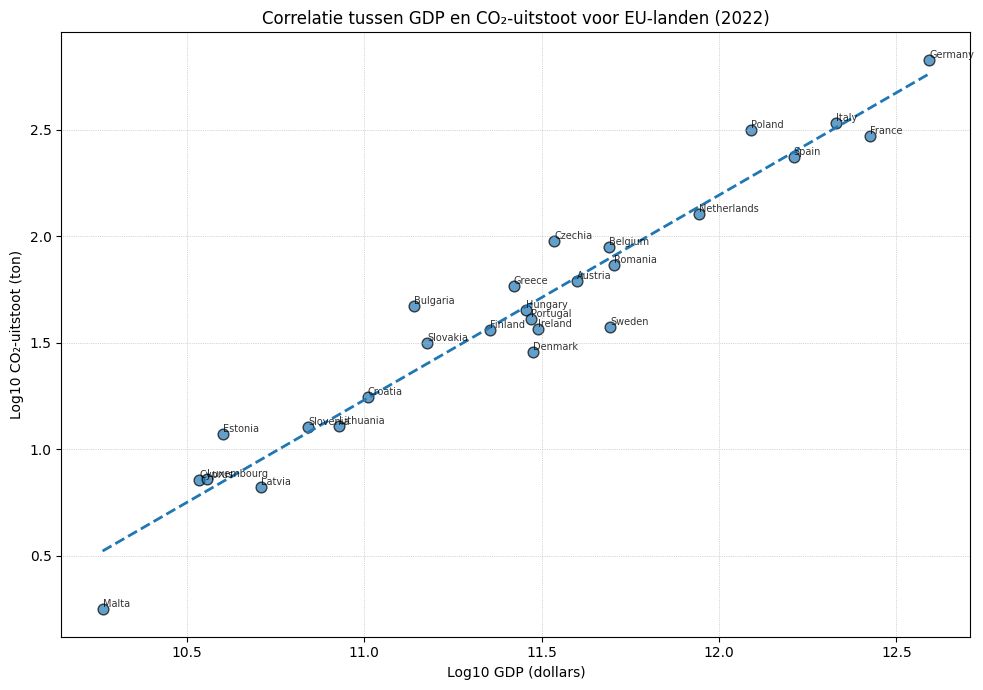

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Data inladen vanaf GitHub (of lokaal opgeslagen bestand)
url = 'https://raw.githubusercontent.com/owid/co2-data/master/owid-co2-data.csv'
df = pd.read_csv(url)

# EU-landenlijst
eu_countries = [
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece',
    'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg',
    'Malta', 'Netherlands', 'Poland', 'Portugal', 'Romania',
    'Slovakia', 'Slovenia', 'Spain', 'Sweden'
]

# Filter op laatste jaar en EU-landen
df_latest = df[df['year'] == 2022]
df_eu = df_latest[df_latest['country'].isin(eu_countries)].dropna(subset=['gdp', 'co2'])

# Log-transformatie om spreiding te verbeteren
x = np.log10(df_eu['gdp'])
y = np.log10(df_eu['co2'])

# Lineaire regressie in log-ruimte
coeffs = np.polyfit(x, y, 1)
fit_line = np.poly1d(coeffs)

# Visualisatie
plt.figure(figsize=(10, 7))
plt.scatter(x, y, s=60, alpha=0.7, edgecolors='k')

# Regressielijn
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, fit_line(xx), linestyle='--', linewidth=2)

# Labels punten (optioneel kleiner en licht)
for i, row in df_eu.iterrows():
    plt.text(np.log10(row['gdp']), np.log10(row['co2']), row['country'],
             fontsize=7, alpha=0.8, ha='left', va='bottom')

# As-labels en titel
plt.xlabel('Log10 GDP (dollars)')
plt.ylabel('Log10 CO₂-uitstoot (ton)')
plt.title('Correlatie tussen GDP en CO₂-uitstoot voor EU-landen (2022)')
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()
